# 실습 1. KMeans 군집화

Breast Cancer 데이터셋을 사용해 KMeans 군집화 흐름을 복습함.

## 데이터셋
- 데이터: scikit-learn `load_breast_cancer`
- 샘플 수: 569개
- feature 수: 30개
- target: `malignant`, `benign`

KMeans 학습에는 target을 사용하지 않음. target은 군집 결과를 나중에 해석하기 위한 비교 기준으로만 사용함.


In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, silhouette_samples

cancer = load_breast_cancer(as_frame=True)
cancer_X = cancer.data.copy()
cancer_y = cancer.target.copy()
cancer_target_names = dict(enumerate(cancer.target_names))

cancer_df = cancer_X.copy()
cancer_df['target'] = cancer_y
cancer_df['target_name'] = cancer_df['target'].map(cancer_target_names)

display(cancer_df.head())
print('feature shape:', cancer_X.shape)
print('target shape:', cancer_y.shape)
print('target names:', cancer.target_names)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target,target_name
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0,malignant
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0,malignant
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0,malignant
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0,malignant
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0,malignant


feature shape: (569, 30)
target shape: (569,)
target names: ['malignant' 'benign']


## 문제 1. KMeans 전 스케일링

KMeans는 거리 기반 알고리즘이므로 `StandardScaler`로 feature 스케일을 맞추세요.

요구사항:
- 변수명은 `cancer_scaler`, `cancer_X_scaled` 사용
- 스케일링된 데이터의 평균과 표준편차 확인

### 실행 결과
```text
scaled mean: 0.0
scaled std: 1.0
```


In [41]:
cancer_scaler = StandardScaler()
cancer_X_scaled = cancer_scaler.fit_transform(cancer_X)


## 문제 2. KMeans 기본 군집화

`KMeans(n_clusters=2)`로 Breast Cancer 데이터를 2개 군집으로 나누세요.

요구사항:
- 변수명은 `cancer_kmeans`, `cancer_cluster_labels` 사용
- 결과를 `cancer_cluster_df`에 저장
- 군집별 샘플 개수와 `inertia_` 확인

### 실행 결과
```text
cluster count 예시
0    375
1    194
inertia: 11595.527
```


In [42]:
cancer_kmeans = KMeans(
    n_clusters=2,
    random_state=42,
)
cancer_cluster_labels = cancer_kmeans.fit_predict(cancer_X_scaled)

cancer_cluster_df = cancer_df.copy()
cancer_cluster_df['cluster'] = cancer_cluster_labels




## 문제 3. 실제 target과 군집 결과 비교

KMeans는 target 없이 학습했지만, 실습 데이터에는 실제 target이 있으므로 교차표로 비교할 수 있음.

요구사항:
- `pd.crosstab()` 사용
- 행은 실제 class, 열은 KMeans cluster
- 결과 변수명은 `cancer_cluster_table` 사용

### 실행 결과
```text
cluster         0    1
actual_class          
benign        339   18
malignant      36  176
```


In [43]:
cluster_target_table = pd.crosstab(
    cancer_cluster_df['target_name'],
    cancer_cluster_df['cluster'],
    rownames = ['actual_class'],
    colnames= ['cluster']

)
display(cluster_target_table)

cluster,0,1
actual_class,,
benign,13,344
malignant,175,37


## 문제 4. PCA 2차원 시각화

30개 feature를 PCA 2차원으로 줄여 실제 class와 KMeans cluster를 나란히 시각화하세요.

요구사항:
- `PCA(n_components=2)` 사용
- 왼쪽 그래프는 실제 class, 오른쪽 그래프는 cluster 기준 색상

### 실행 결과
```text
확인 포인트: 실제 class 분포와 KMeans cluster 분포가 얼마나 비슷한지 비교
```
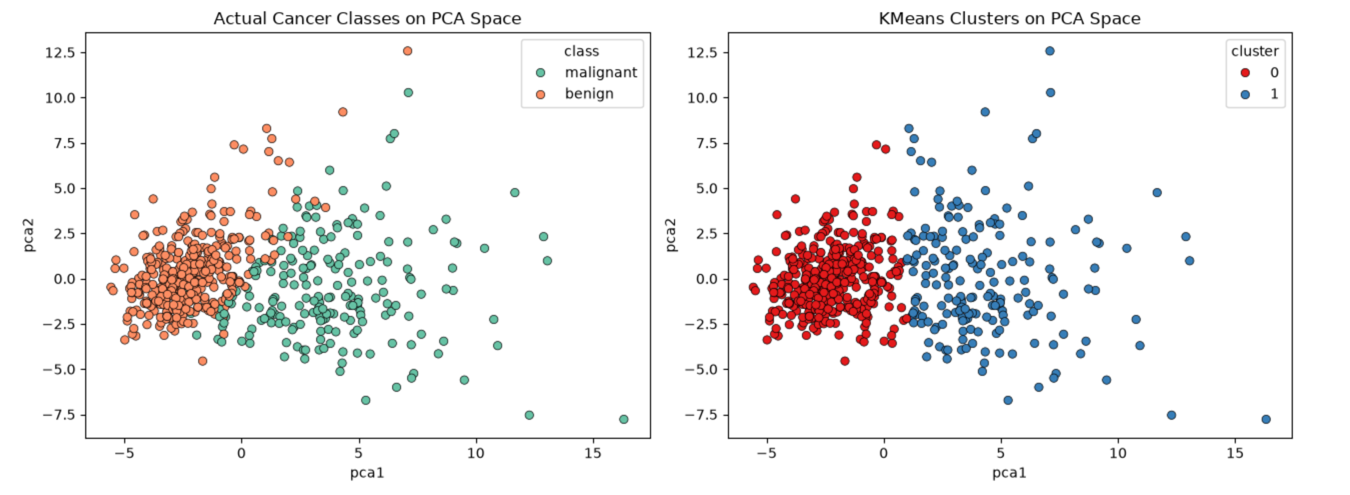


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target,target_name,cluster,pc1,pc2
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,0.66560,0.7119,0.2654,0.4601,0.11890,0,malignant,0,9.192837,1.948583
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,0.18660,0.2416,0.1860,0.2750,0.08902,0,malignant,0,2.387802,-3.768172
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,0.42450,0.4504,0.2430,0.3613,0.08758,0,malignant,0,5.733896,-1.075174
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,0.86630,0.6869,0.2575,0.6638,0.17300,0,malignant,0,7.122953,10.275589
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,0.20500,0.4000,0.1625,0.2364,0.07678,0,malignant,0,3.935302,-1.948072
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,0.21130,0.4107,0.2216,0.2060,0.07115,0,malignant,0,6.439315,-3.576817
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,0.19220,0.3215,0.1628,0.2572,0.06637,0,malignant,0,3.793382,-3.584048
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,0.30940,0.3403,0.1418,0.2218,0.07820,0,malignant,0,1.256179,-1.902297
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,0.86810,0.9387,0.2650,0.4087,0.12400,0,malignant,0,10.374794,1.672010


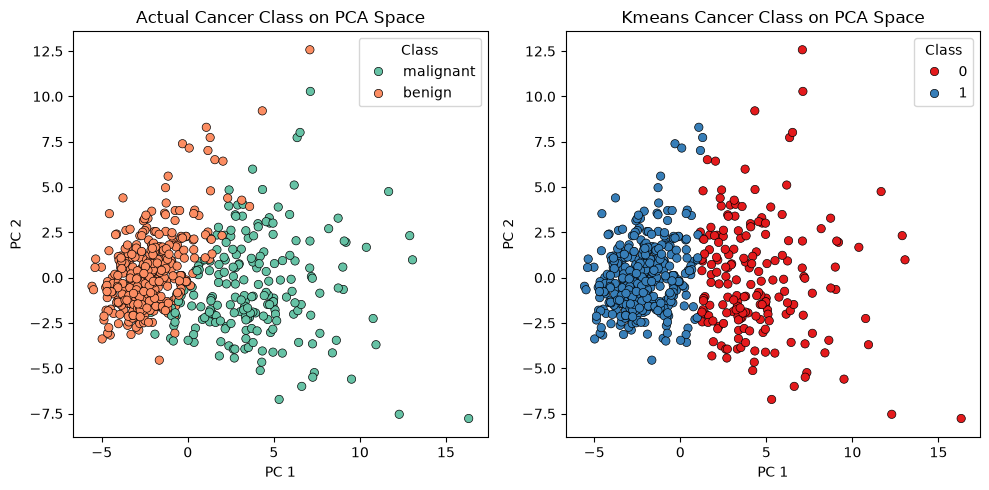

In [44]:
pca = PCA(n_components=2)
pca_X_scaled =pca.fit_transform(cancer_X_scaled)


cancer_cluster_df['pc1'] = pca_X_scaled[:,0]
cancer_cluster_df['pc2'] = pca_X_scaled[:,1]
display(cancer_cluster_df)

fig,axes = plt.subplots(1,2, figsize=(10,5))

sns.scatterplot(
    data=cancer_cluster_df,
    x='pc1',
    y='pc2',
    hue='target_name',
    palette='Set2',
    edgecolor='black',
    ax=axes[0]

)
axes[0].set_title('Actual Cancer Class on PCA Space')
axes[0].set_xlabel('PC 1')
axes[0].set_ylabel('PC 2')
axes[0].legend(title='Class')



sns.scatterplot(
    data=cancer_cluster_df,
    x='pc1',
    y='pc2',
    hue='cluster',
    palette='Set1',
    edgecolor='black',
    ax=axes[1]

)
axes[1].set_title('Kmeans Cancer Class on PCA Space')
axes[1].set_xlabel('PC 1')
axes[1].set_ylabel('PC 2')
axes[1].legend(title='Class')

plt.tight_layout()
plt.show()

## 문제 5. k 후보별 inertia와 silhouette score 비교

`k=2`부터 `k=6`까지 KMeans를 학습하고 inertia와 silhouette score를 비교하세요.

요구사항:
- 결과 변수명은 `cancer_k_result_df` 사용
- `inertia`, `silhouette_score` 컬럼 포함

### 실행 결과
```text
   k     inertia  silhouette_score
0  2  11595.5266            0.3434
1  3  10061.7978            0.3144
2  4   9258.9891            0.2833
3  5   8558.6607            0.1582
4  6   7970.2638            0.1604
```


In [45]:
k_values = range(2,7)

cancer_k_result = []

for k in k_values:

    model = KMeans(
        n_clusters=k,
        n_init=10,
        max_iter=300,
        random_state=42,
    )
    labels = model.fit_predict(cancer_X_scaled)
    score = silhouette_score(cancer_X_scaled, labels)

    cancer_k_result.append({
        'k': k,
        'inertia':model.inertia_,
        'silhouette_score_score': score

    })

cancer_k_result_df = pd.DataFrame(cancer_k_result)
display(cancer_k_result_df.round(4))



,k,inertia,silhouette_score_score
0,2,11595.5266,0.3434
1,3,10061.7978,0.3144
2,4,9258.9891,0.2833
3,5,8558.6607,0.1582
4,6,7970.2638,0.1604
